# Detecting Topic Merges and Splits in Dynamic Political Conversations

Cláudia Oliveira 

Supervisor - Prof. Dr. Álvaro Figueira

Faculty of Science, University of Porto

### Packages

In [ ]:
import pandas as pd
import os
os.chdir("../..")

### Datasets

In [ ]:
bertildarelationsun = pd.read_csv("datasets/undebates/un_bertilda_merge_split_relations.csv", encoding="utf-8", low_memory=False)
bertildarelationsstateofunion = pd.read_csv("datasets/stateofunion/stateofunion_bertilda_merge_split_relations.csv", encoding="utf-8", low_memory=False)
detmrelationsun = pd.read_csv("datasets/undebates/un_detm_relations.csv", encoding="utf-8", low_memory=False)
detmrelationsstateofunion = pd.read_csv("datasets/stateofunion/stateofunion_detm_relations.csv", encoding="utf-8", low_memory=False)
dtmrelationsun = pd.read_csv("datasets/undebates/undebates_dtm_relations.csv", encoding="utf-8", low_memory=False)
dtmrelationsstateofunion = pd.read_csv("datasets/stateofunion/stateofunion_dtm_relations.csv", encoding="utf-8", low_memory=False)

### Util

In [5]:
def edge_summary(df):
    weak_edge_penalty = (df["similarity"] < 0.2).mean()  
    return pd.Series({
        "EC_mean": df["similarity"].mean(),
        "EC_median": df["similarity"].median(),
        "EC_P10": df["similarity"].quantile(0.10),
        "EC_P90": df["similarity"].quantile(0.90),
        "WeakEdgePenalty": weak_edge_penalty,
        "NumEdges": len(df)
    })

## Edge coherence 

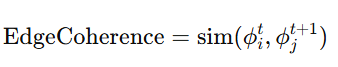

### UN Debates

#### BERTilda

In [ ]:
import pandas as pd
import ast

list_cols = [
    "successors_similarities",
    "antecedents_similarities"
]

for col in list_cols:
    if col in bertildarelationsun.columns:
        bertildarelationsun[col] = bertildarelationsun[col].apply(
            lambda x: ast.literal_eval(x) if isinstance(x, str) else x
        )
        
edges = []

for _, row in bertildarelationsun.iterrows():
    relation = row["relation"]

    # disappeared 
    if relation == "disappeared":
        continue

    # merge 
    if relation == "merge" and isinstance(row["antecedents_similarities"], list):
        for sim in row["antecedents_similarities"]:
            edges.append({
                "relation": "merge",
                "similarity": sim,
                "window1": row["window1"],
                "window2": row["window2"]
            })

    elif relation in ["split", "continued", "unclear"] and isinstance(row["successors_similarities"], list):
        for sim in row["successors_similarities"]:
            edges.append({
                "relation": relation,
                "similarity": sim,
                "window1": row["window1"],
                "window2": row["window2"]
            })

edges_df = pd.DataFrame(edges)

summary = edge_summary(edges_df)
summary_df = pd.DataFrame([summary])

print(summary_df)

    EC_mean  EC_median  EC_P10  EC_P90  WeakEdgePenalty  NumEdges
0  0.751425      0.732   0.631  0.9056              0.0      73.0


In [52]:
summary_df = edges_df.groupby("relation", as_index=False).apply(edge_summary, include_groups=False).reset_index(drop=True)
summary_df = summary_df.reset_index(drop=True)
print(summary_df)

    relation   EC_mean  EC_median  EC_P10  EC_P90  WeakEdgePenalty  NumEdges
0  continued  0.806571     0.7790  0.7274  0.9305              0.0      28.0
1      merge  0.702929     0.7020  0.6192  0.7576              0.0      14.0
2      split  0.749200     0.7305  0.6261  0.9408              0.0      10.0
3    unclear  0.711286     0.6880  0.6060  0.8590              0.0      21.0


#### Tomotopy DTM

In [6]:
edges_df = dtmrelationsun

summary = edge_summary(edges_df)
summary_df = pd.DataFrame([summary])

print(summary_df)

    EC_mean  EC_median    EC_P10   EC_P90  WeakEdgePenalty  NumEdges
0  0.993346   0.995757  0.985973  0.99843              0.0    2250.0


#### DETM

In [7]:
edges_df = detmrelationsun

summary = edge_summary(edges_df)
summary_df = pd.DataFrame([summary])

print(summary_df)

    EC_mean  EC_median    EC_P10    EC_P90  WeakEdgePenalty  NumEdges
0  0.116266   0.116955  0.040525  0.192928         0.920444    2250.0


### State of Union

#### BERTilda

In [ ]:
import pandas as pd
import ast

list_cols = [
    "successors_similarities",
    "antecedents_similarities"
]

for col in list_cols:
    if col in bertildarelationsstateofunion.columns:
        bertildarelationsstateofunion[col] = bertildarelationsstateofunion[col].apply(
            lambda x: ast.literal_eval(x) if isinstance(x, str) else x
        )
        
edges = []

for _, row in bertildarelationsstateofunion.iterrows():
    relation = row["relation"]

    # disappeared 
    if relation == "disappeared":
        continue

    # merge 
    if relation == "merge" and isinstance(row["antecedents_similarities"], list):
        for sim in row["antecedents_similarities"]:
            edges.append({
                "relation": "merge",
                "similarity": sim,
                "window1": row["window1"],
                "window2": row["window2"]
            })

    elif relation in ["split", "continued", "unclear"] and isinstance(row["successors_similarities"], list):
        for sim in row["successors_similarities"]:
            edges.append({
                "relation": relation,
                "similarity": sim,
                "window1": row["window1"],
                "window2": row["window2"]
            })

edges_df = pd.DataFrame(edges)

summary = edge_summary(edges_df)
summary_df = pd.DataFrame([summary])

print(summary_df)

    EC_mean  EC_median  EC_P10  EC_P90  WeakEdgePenalty  NumEdges
0  0.753611      0.747   0.625   0.888              0.0     833.0


In [ ]:
summary_df = edges_df.groupby("relation", as_index=False).apply(edge_summary, include_groups=False).reset_index(drop=True)
summary_df = summary_df.reset_index(drop=True)
print(summary_df)

    relation   EC_mean  EC_median  EC_P10  EC_P90  WeakEdgePenalty  NumEdges
0  continued  0.814387     0.8060  0.7240  0.9220              0.0     481.0
1      merge  0.690114     0.6730  0.6083  0.8030              0.0      44.0
2      split  0.693808     0.6710  0.6081  0.8218              0.0      52.0
3    unclear  0.662480     0.6525  0.6110  0.7035              0.0     256.0


#### Tomotopy DTM

In [7]:
edges_df = dtmrelationsstateofunion 

summary = edge_summary(edges_df)
summary_df = pd.DataFrame([summary])

print(summary_df)

    EC_mean  EC_median    EC_P10    EC_P90  WeakEdgePenalty  NumEdges
0  0.886435   0.913401  0.742489  0.985861              0.0   11300.0


#### DETM

In [12]:
edges_df = detmrelationsstateofunion

summary = edge_summary(edges_df)
summary_df = pd.DataFrame([summary])

print(summary_df)

    EC_mean  EC_median   EC_P10   EC_P90  WeakEdgePenalty  NumEdges
0  0.106688   0.106821  0.02991  0.18307         0.942035   11300.0


## Path stability

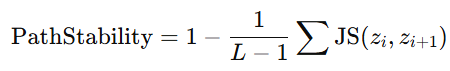

### UN Debates

#### BERTilda

#### Tomotopy DTM

#### DETM

### State of Union

#### BERTilda

#### Tomotopy DTM

#### DETM

## Birth/death rate

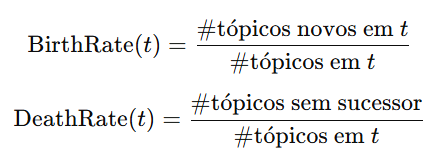

### UN Debates

#### BERTilda

#### Tomotopy DTM

#### DETM

### State of Union

#### BERTilda

#### Tomotopy DTM

#### DETM